In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv("heart_attack_data.csv")

In [44]:
df.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,55,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [45]:
df.isna().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

### Removing Nan/Null values if exists ###

In [46]:
df.dropna(axis = 0, inplace = True) 
print(df.shape)

(289, 14)


In [47]:
df.duplicated().sum()

1

In [48]:
df.drop_duplicates(inplace=True)

In [49]:
df.nunique().sort_values()

sex           2
fbs           2
exng          2
output        2
restecg       3
slp           3
cp            4
thall         4
caa           5
oldpeak      39
age          41
trtbps       47
thalachh     90
chol        147
dtype: int64

In [50]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000
mean,54.065972,0.677083,1.017361,131.354167,248.215278,0.145833,0.513889,150.152778,0.319444,1.011111,1.416667,0.701389,2.315972,0.569444
std,9.099096,0.468405,1.027349,17.544555,51.505646,0.353553,0.514407,22.899970,0.467073,1.133900,0.613438,1.005766,0.596875,0.496016
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,212.000000,0.000000,0.000000,135.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,1.000000,130.000000,243.000000,0.000000,1.000000,154.000000,0.000000,0.650000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,276.250000,0.000000,1.000000,167.250000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


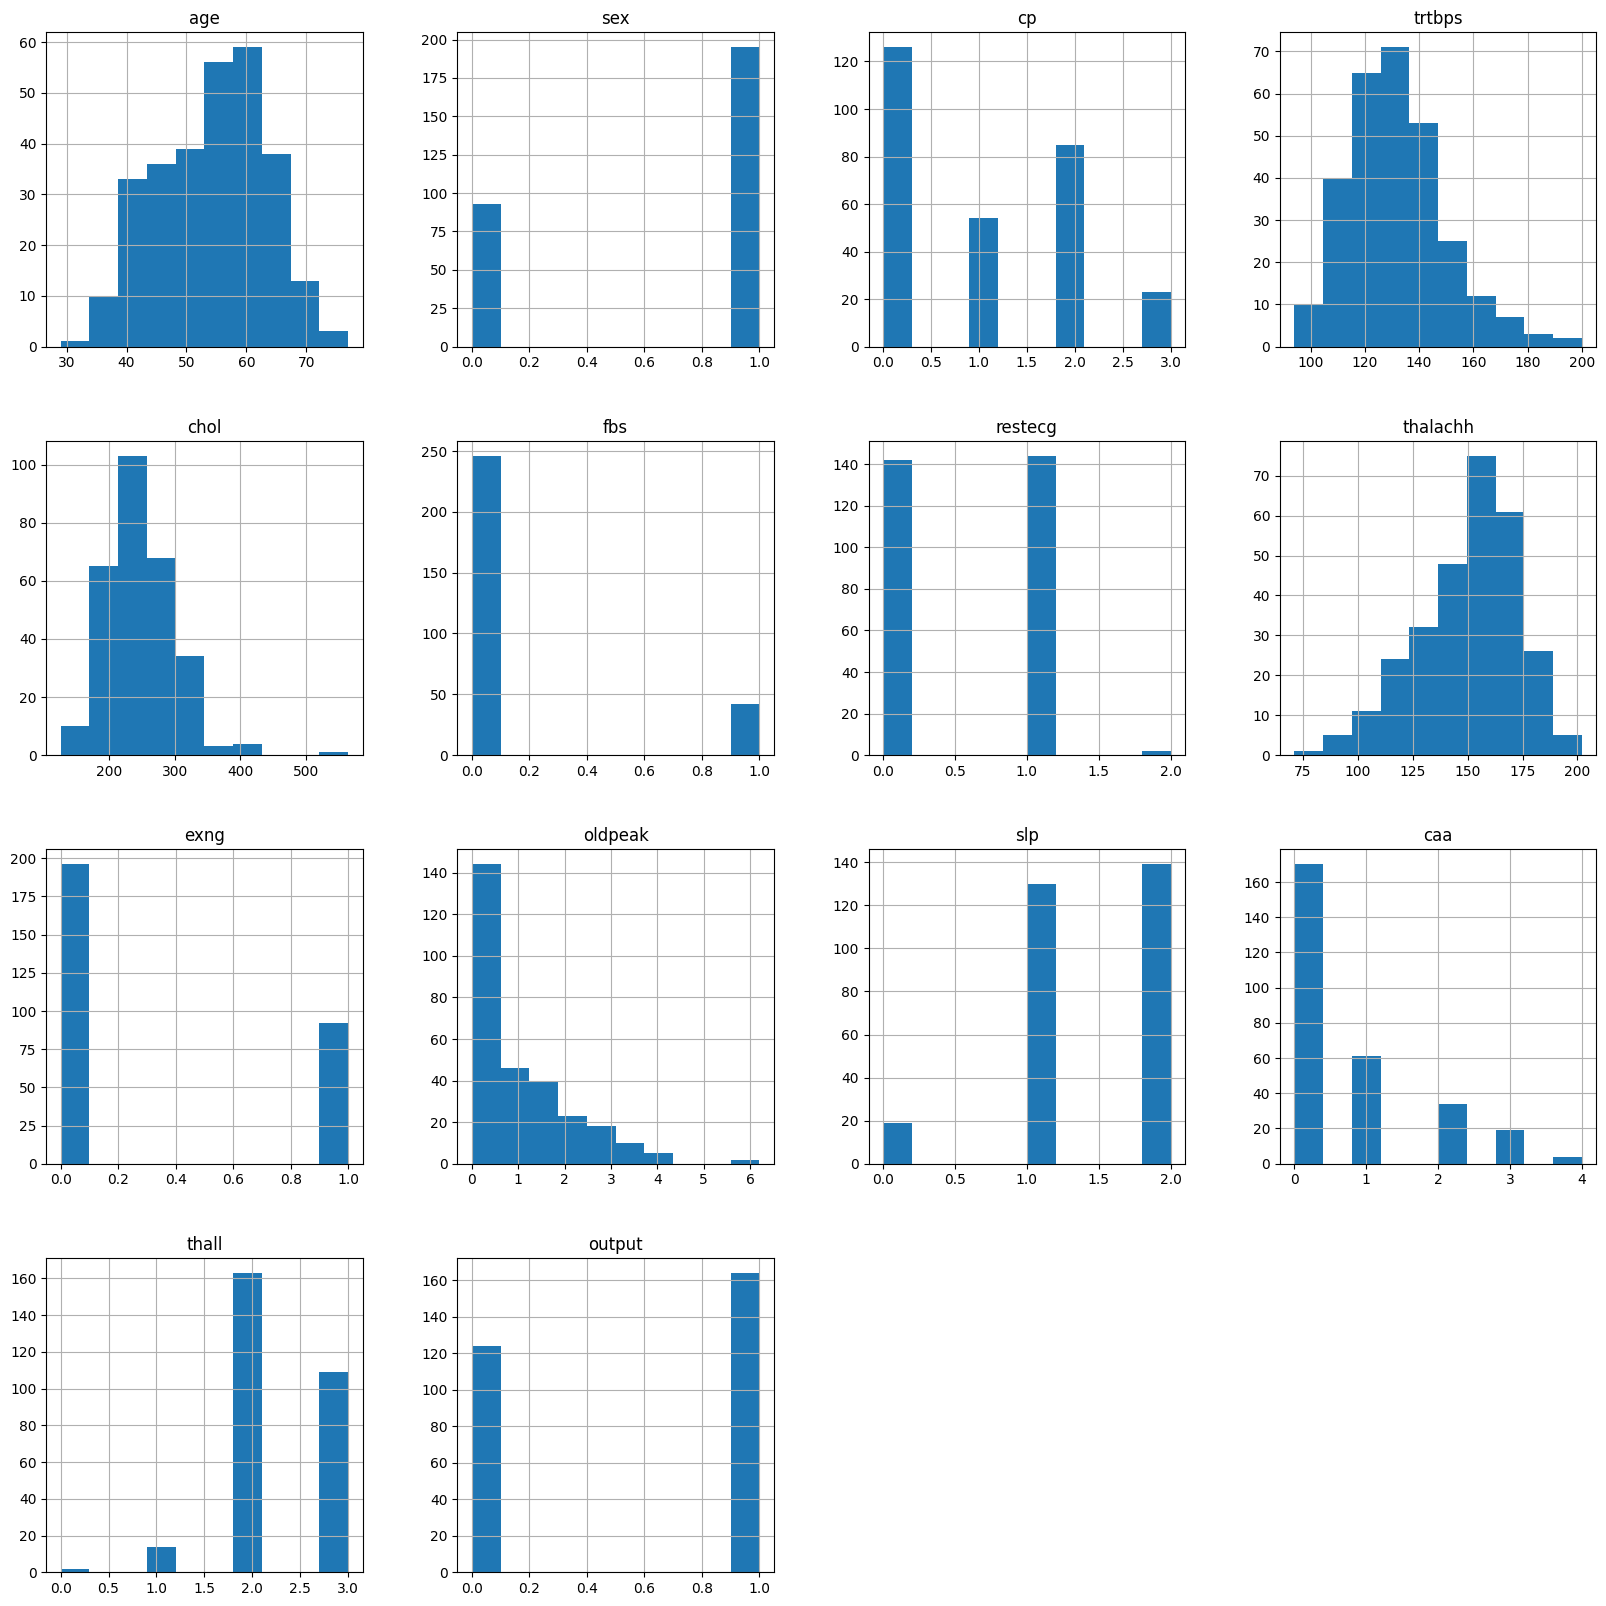

In [51]:
df.hist(figsize=(20,20))
plt.show()

<Axes: >

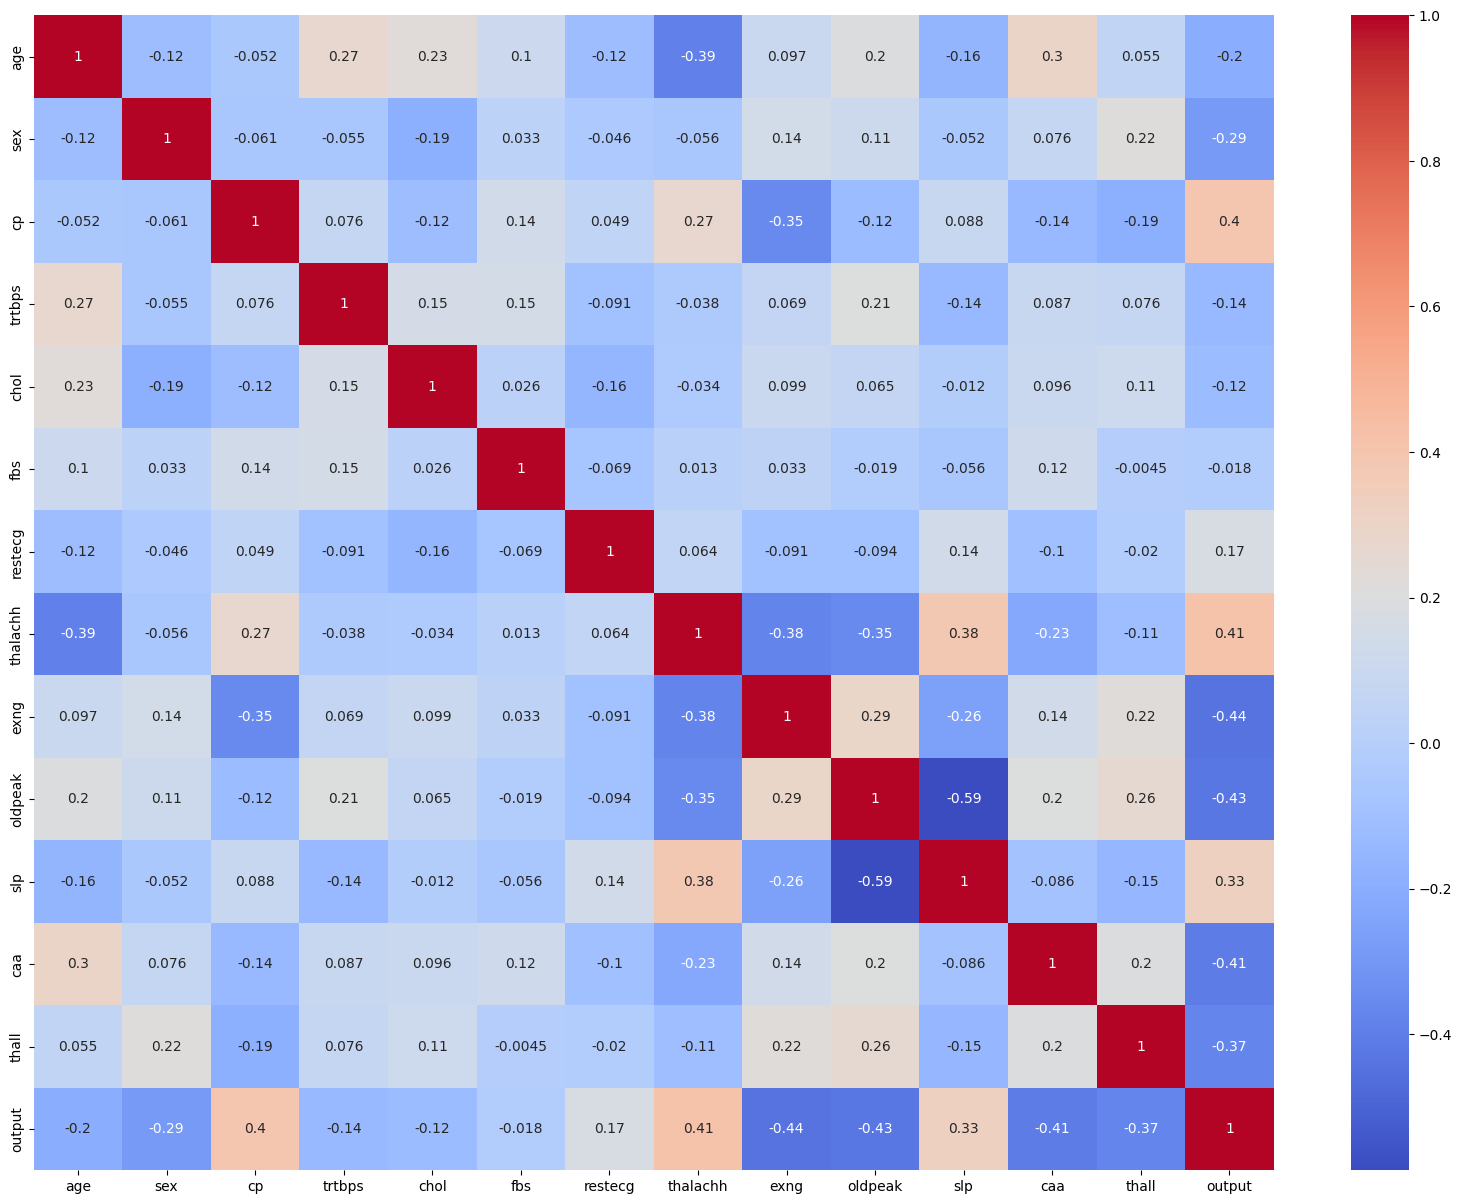

In [52]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

In [53]:
for i in df.columns:
    print (i,df[i].unique())

age [60 35 41 55 56 44 52 57 54 48 49 64 50 58 66 40 69 59 42 61 71 51 65 53
 46 45 39 47 62 63 34 29 43 67 68 37 74 76 70 38 77]
sex [1 0]
cp [3 2 1 0]
trtbps [145 130 120 140 172 150 110 135 160 105 125 142 155 104 138 128 108 134
 122 115 118 100 124  94 112 102 152 101 132 148 178 129 180 136 126 106
 156 170 146 117 200 165 174 192 144 123 154]
chol [233 250 204 236 354 192 294 263 199 168 239 275 266 211 283 219 340 226
 247 234 243 302 212 175 417 197 198 177 273 213 304 232 269 360 308 245
 208 264 321 325 235 257 216 256 231 141 252 201 222 260 182 303 265 309
 186 203 183 220 209 258 227 261 221 205 240 318 298 564 277 214 248 255
 207 223 288 160 394 315 246 244 270 195 196 254 126 313 262 215 193 271
 268 267 210 295 306 178 242 180 228 149 278 253 342 157 286 229 284 224
 206 167 230 335 276 353 225 330 290 172 305 188 282 185 326 274 164 307
 249 341 407 217 174 281 289 322 299 300 293 184 409 259 200 327 237 218
 319 166 311]
fbs [1 0]
restecg [0 1 2]
thalachh [150 187 1

In [54]:
cat_var=df[[ 'sex','cp', 'restecg', 'slp', 'thall','exng','caa']]
con_var=df[['age', 'trtbps', 'thalachh', 'oldpeak',]]

In [55]:
categorical = cat_var.columns
continous = con_var.columns

In [56]:
from sklearn.preprocessing import StandardScaler


In [57]:
data_encoded = pd.get_dummies(df, columns=categorical, drop_first=True)
data_encoded= data_encoded.drop('output',axis=1)


In [58]:
data_encoded.head()

,age,trtbps,chol,fbs,thalachh,oldpeak,sex_1,cp_1,cp_2,cp_3,...,slp_1,slp_2,thall_1,thall_2,thall_3,exng_1,caa_1,caa_2,caa_3,caa_4
0,60,145,233,1,150,2.3,True,False,False,True,...,False,False,True,False,False,False,False,False,False,False
1,35,130,250,0,187,3.5,True,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,41,130,204,0,172,1.4,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
3,55,120,236,0,178,0.8,True,True,False,False,...,False,True,False,True,False,False,False,False,False,False
4,56,120,354,0,163,0.6,False,False,False,False,...,False,True,False,True,False,True,False,False,False,False


In [59]:
data_encoded= data_encoded.drop(columns=['sex_1'],axis=1)

In [60]:
st_scaler = StandardScaler()
model_df= st_scaler.fit_transform(data_encoded)
model_df =  pd.DataFrame(model_df, columns = data_encoded.columns)
model_df.head()

,age,trtbps,chol,fbs,thalachh,oldpeak,cp_1,cp_2,cp_3,restecg_1,...,slp_1,slp_2,thall_1,thall_2,thall_3,exng_1,caa_1,caa_2,caa_3,caa_4
0,0.653291,0.779136,-0.295924,2.420153,-0.006683,1.138665,-0.480384,-0.647085,3.394369,-1.0,...,-0.907075,-0.965860,4.423961,-1.141928,-0.780345,-0.685119,-0.518384,-0.365866,-0.265767,-0.118678
1,-2.099017,-0.077319,0.034711,-0.413197,1.611852,2.198801,-0.480384,1.545392,-0.294606,1.0,...,-0.907075,-0.965860,-0.226042,0.875712,-0.780345,-0.685119,-0.518384,-0.365866,-0.265767,-0.118678
2,-1.438463,-0.077319,-0.859949,-0.413197,0.955689,0.343563,2.081666,-0.647085,-0.294606,-1.0,...,-0.907075,1.035347,-0.226042,0.875712,-0.780345,-0.685119,-0.518384,-0.365866,-0.265767,-0.118678
3,0.102829,-0.648288,-0.237577,-0.413197,1.218154,-0.186505,2.081666,-0.647085,-0.294606,1.0,...,-0.907075,1.035347,-0.226042,0.875712,-0.780345,-0.685119,-0.518384,-0.365866,-0.265767,-0.118678
4,0.212922,-0.648288,2.057422,-0.413197,0.561991,-0.363195,-0.480384,-0.647085,-0.294606,1.0,...,-0.907075,1.035347,-0.226042,0.875712,-0.780345,1.459601,-0.518384,-0.365866,-0.265767,-0.118678


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [62]:
x = model_df
y = df["output"] 

In [63]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [64]:
print("x_Train : ", x_train.shape)
print("x_Test  : ", x_test.shape)
print("y_Train : ", y_train.shape)
print("y_Test  : ", y_test.shape)

x_Train :  (230, 21)
x_Test  :  (58, 21)
y_Train :  (230,)
y_Test  :  (58,)


### Normal Method ###

In [65]:

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score


Train Accuracy 0.8913043478260869
Train Classification Report
               precision    recall  f1-score   support

           0       0.92      0.81      0.86        97
           1       0.88      0.95      0.91       133

    accuracy                           0.89       230
   macro avg       0.90      0.88      0.89       230
weighted avg       0.89      0.89      0.89       230

Test Accuracy 0.8103448275862069
Test Classification Report
               precision    recall  f1-score   support

           0       0.83      0.74      0.78        27
           1       0.79      0.87      0.83        31

    accuracy                           0.81        58
   macro avg       0.81      0.81      0.81        58
weighted avg       0.81      0.81      0.81        58



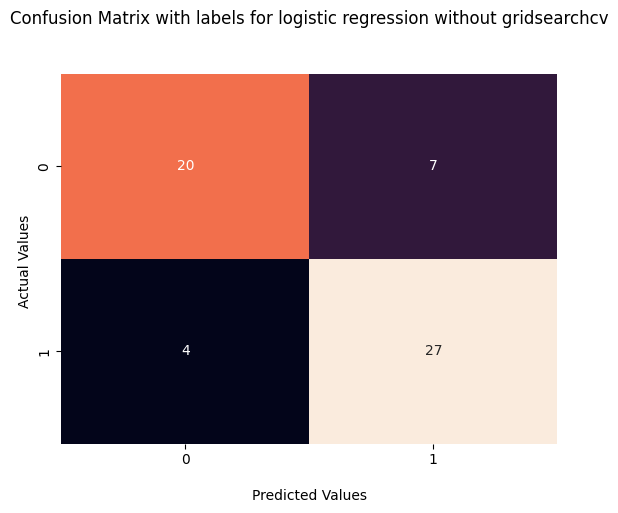

In [66]:
### logistic regression ###

LR_model = LogisticRegression()
LR_model.fit(x_train, y_train)
LR_xpred=LR_model.predict(x_train)
LR_ypred = LR_model.predict(x_test)
print("Train Accuracy", accuracy_score(y_train, LR_xpred))
print("Train Classification Report\n", classification_report(y_train,LR_xpred))

print("Test Accuracy", accuracy_score(y_test, LR_ypred))
print("Test Classification Report\n", classification_report(y_test,LR_ypred))


cf=confusion_matrix(y_test,LR_ypred)
mat2=sns.heatmap(cf,annot=True, cbar=False)
mat2.set_title('Confusion Matrix with labels for logistic regression without gridsearchcv\n\n')
mat2.set_xlabel('\nPredicted Values')
mat2.set_ylabel('Actual Values ')
plt.show()

Train Accuracy 0.8782608695652174
Train Classification Report
               precision    recall  f1-score   support

           0       0.91      0.79      0.85        97
           1       0.86      0.94      0.90       133

    accuracy                           0.88       230
   macro avg       0.88      0.87      0.87       230
weighted avg       0.88      0.88      0.88       230

Test Accuracy 0.8620689655172413
Test Classification Report
               precision    recall  f1-score   support

           0       0.95      0.74      0.83        27
           1       0.81      0.97      0.88        31

    accuracy                           0.86        58
   macro avg       0.88      0.85      0.86        58
weighted avg       0.88      0.86      0.86        58



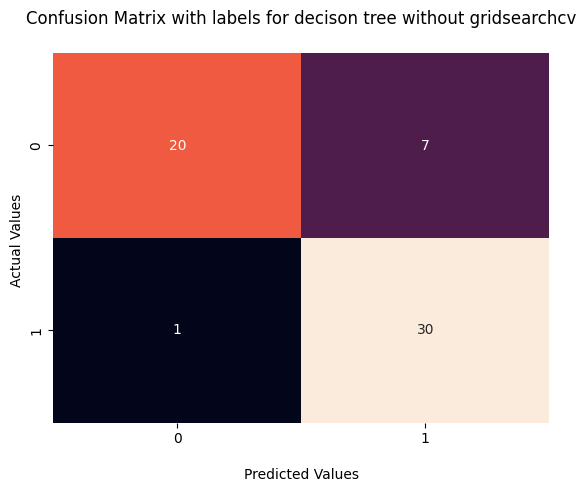

In [67]:
### decision tree ###

dc_model = DecisionTreeClassifier(criterion='gini', max_depth=4)
dc_model.fit(x_train, y_train)
dc_xpred=dc_model.predict(x_train)
dc_ypred = dc_model.predict(x_test)
print("Train Accuracy", accuracy_score(y_train, dc_xpred))
print("Train Classification Report\n", classification_report(y_train,dc_xpred))

print("Test Accuracy", accuracy_score(y_test, dc_ypred))
print("Test Classification Report\n", classification_report(y_test,dc_ypred))
cf=confusion_matrix(y_test,dc_ypred)
mat2=sns.heatmap(cf,annot=True, cbar=False)
mat2.set_title('Confusion Matrix with labels for decison tree without gridsearchcv\n')
mat2.set_xlabel('\nPredicted Values')
mat2.set_ylabel('Actual Values ')
plt.show()

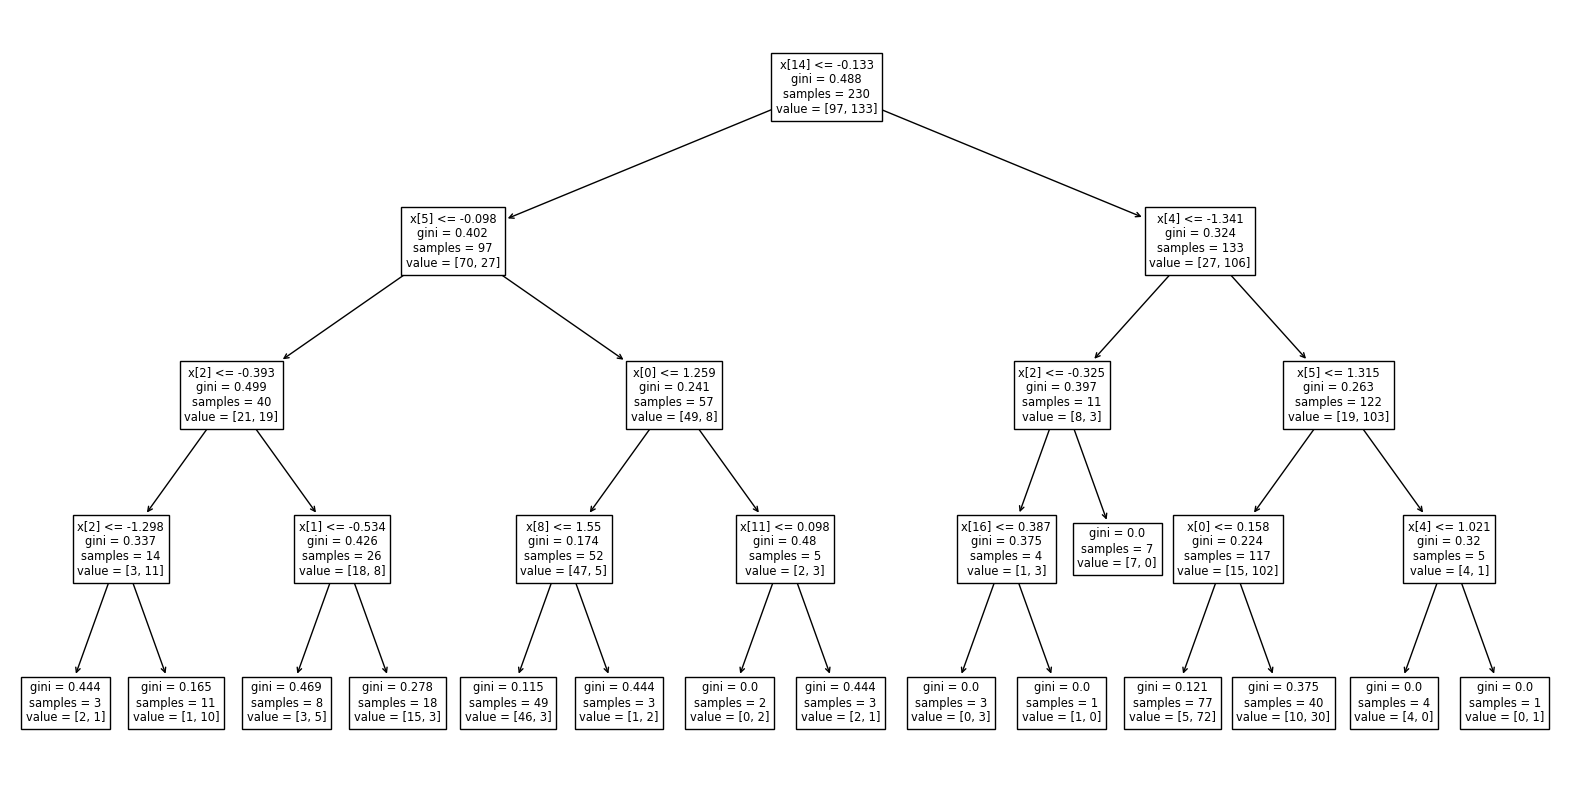

In [68]:
from sklearn import tree

fig, ax = plt.subplots(figsize=(20, 10)) 
tree.plot_tree(dc_model.fit(x_train, y_train), ax=ax)
plt.show()

Train Accuracy 0.9173913043478261
Train Classification Report
               precision    recall  f1-score   support

           0       0.93      0.87      0.90        97
           1       0.91      0.95      0.93       133

    accuracy                           0.92       230
   macro avg       0.92      0.91      0.91       230
weighted avg       0.92      0.92      0.92       230

Test Accuracy 0.7931034482758621
Test Classification Report
               precision    recall  f1-score   support

           0       0.80      0.74      0.77        27
           1       0.79      0.84      0.81        31

    accuracy                           0.79        58
   macro avg       0.79      0.79      0.79        58
weighted avg       0.79      0.79      0.79        58



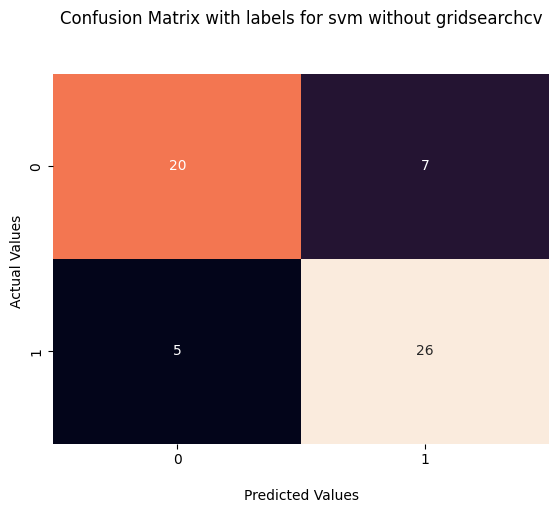

In [69]:
### svm model ###

svm_model = SVC()
svm_model.fit(x_train, y_train)
svm_xpred=svm_model.predict(x_train)
svm_ypred = svm_model.predict(x_test)
print("Train Accuracy", accuracy_score(y_train, svm_xpred))
print("Train Classification Report\n", classification_report(y_train,svm_xpred))

print("Test Accuracy", accuracy_score(y_test, svm_ypred))
print("Test Classification Report\n", classification_report(y_test,svm_ypred))
cf=confusion_matrix(y_test,svm_ypred)
mat2=sns.heatmap(cf,annot=True, cbar=False)
mat2.set_title('Confusion Matrix with labels for svm without gridsearchcv\n\n')
mat2.set_xlabel('\nPredicted Values')
mat2.set_ylabel('Actual Values ')
plt.show()

### hypertuning grid search cv method ###


In [70]:
from sklearn.model_selection import GridSearchCV
model_params = {
    'Logistic_Regression': {
        'model': LogisticRegression(),
        'params' : {
            'penalty':['l1', 'l2', 'elasticnet'],
            'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
            'max_iter': [100, 120, 80, 70],
            'multi_class': ['auto', 'ovr', 'multinomial'],
        }
    },
    'decision_tree':{
        'model':DecisionTreeClassifier(),
        'params':{
            'splitter':['best','random'],
            'max_features': ['auto', 'sqrt', 'log2'],
            'max_depth' : [4,5,6,7,8],
            'criterion' :['gini', 'entropy']
        }
    },
    'SVM_Classifier':{
        'model' : SVC(),
        'params':{
            'kernel' : ['rbf','poly','sigmoid','linear'],
            'gamma' : ['scale','auto'],
        }
    }
    }
    


In [71]:
scores = []

from sklearn.model_selection import GridSearchCV
for model_name, mp in model_params.items():
    clf =  GridSearchCV(mp['model'], mp['params'], 
                          verbose=True,
                          cv= 5,
                          n_jobs= 1,
                          scoring='accuracy')
    clf.fit(x_train,y_train) 
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
best = pd.DataFrame(scores,columns=['model','best_score','best_params'])
best

Fitting 5 folds for each of 180 candidates, totalling 900 fits


C:\Users\Manikanta\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Manikanta\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Manikanta\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Manikanta\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Manikanta\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.w

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\Manikanta\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
100 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Manikanta\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Manikanta\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py", line 1145, in wrapper
    estimator._validate_params()
  File "C:\Users\Manikanta\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py", line 638, in _validate

,model,best_score,best_params
0,Logistic_Regression,0.869565,"{'max_iter': 100, 'multi_class': 'auto', 'pena..."
1,decision_tree,0.813043,"{'criterion': 'entropy', 'max_depth': 7, 'max_..."
2,SVM_Classifier,0.860870,"{'gamma': 'scale', 'kernel': 'linear'}"


In [72]:
### logistic regrseeion ###

best.best_params[0]

{'max_iter': 100,
 'multi_class': 'auto',
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [73]:
lr_model= LogisticRegression(solver = 'newton-cg',
                           penalty = 'l2', 
                           max_iter =100,
                           multi_class = 'auto')
lr_model.fit(x_train,y_train)

LogisticRegression(solver='newton-cg')

Train Accuracy 0.8913043478260869
Train Classification Report
               precision    recall  f1-score   support

           0       0.92      0.81      0.86        97
           1       0.88      0.95      0.91       133

    accuracy                           0.89       230
   macro avg       0.90      0.88      0.89       230
weighted avg       0.89      0.89      0.89       230

Test Accuracy 0.8103448275862069
Test Classification Report
               precision    recall  f1-score   support

           0       0.83      0.74      0.78        27
           1       0.79      0.87      0.83        31

    accuracy                           0.81        58
   macro avg       0.81      0.81      0.81        58
weighted avg       0.81      0.81      0.81        58



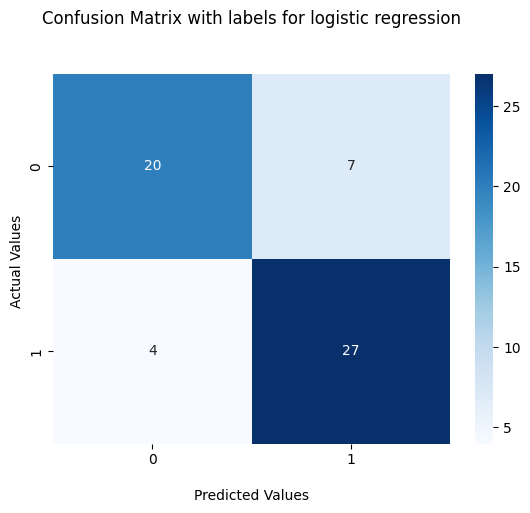

In [74]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

lr_ytrain=lr_model.predict(x_train)
lr_ytest =lr_model.predict(x_test)
print("Train Accuracy", accuracy_score(y_train, lr_ytrain))
print("Train Classification Report\n", classification_report(y_train,lr_ytrain))

print("Test Accuracy", accuracy_score(y_test,lr_ytest))
print("Test Classification Report\n", classification_report(y_test,lr_ytest))
cf_matrix=confusion_matrix(y_test,lr_ytest)
matr = sns.heatmap(cf_matrix, annot=True, cmap='Blues')

matr.set_title('Confusion Matrix with labels for logistic regression\n\n')
matr.set_xlabel('\nPredicted Values')
matr.set_ylabel('Actual Values ')
plt.show()


In [75]:
### decision tree ###
best.best_params[1]

{'criterion': 'entropy',
 'max_depth': 7,
 'max_features': 'sqrt',
 'splitter': 'random'}

In [76]:
tree_model = DecisionTreeClassifier(criterion = 'gini',
                               max_depth = 5,
                               max_features = 'log2',
                               splitter = 'random')
tree_model.fit(x_train,y_train)


DecisionTreeClassifier(max_depth=5, max_features='log2', splitter='random')

Train Accuracy 0.8043478260869565
Train Classification Report
               precision    recall  f1-score   support

           0       0.76      0.78      0.77        97
           1       0.84      0.82      0.83       133

    accuracy                           0.80       230
   macro avg       0.80      0.80      0.80       230
weighted avg       0.81      0.80      0.80       230

Test Accuracy 0.6896551724137931
Test Classification Report
               precision    recall  f1-score   support

           0       0.66      0.70      0.68        27
           1       0.72      0.68      0.70        31

    accuracy                           0.69        58
   macro avg       0.69      0.69      0.69        58
weighted avg       0.69      0.69      0.69        58



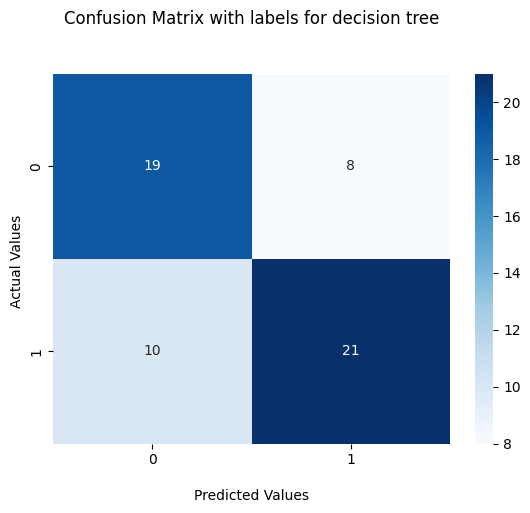

In [77]:
tree_ytrain=tree_model.predict(x_train)
tree_ytest =tree_model.predict(x_test)
print("Train Accuracy", accuracy_score(y_train, tree_ytrain))
print("Train Classification Report\n", classification_report(y_train,tree_ytrain))

print("Test Accuracy", accuracy_score(y_test,tree_ytest))
print("Test Classification Report\n", classification_report(y_test,tree_ytest))
cf_matrix=confusion_matrix(y_test,tree_ytest)
matr = sns.heatmap(cf_matrix, annot=True, cmap='Blues')

matr.set_title('Confusion Matrix with labels for decision tree\n\n')
matr.set_xlabel('\nPredicted Values')
matr.set_ylabel('Actual Values ')
plt.show()

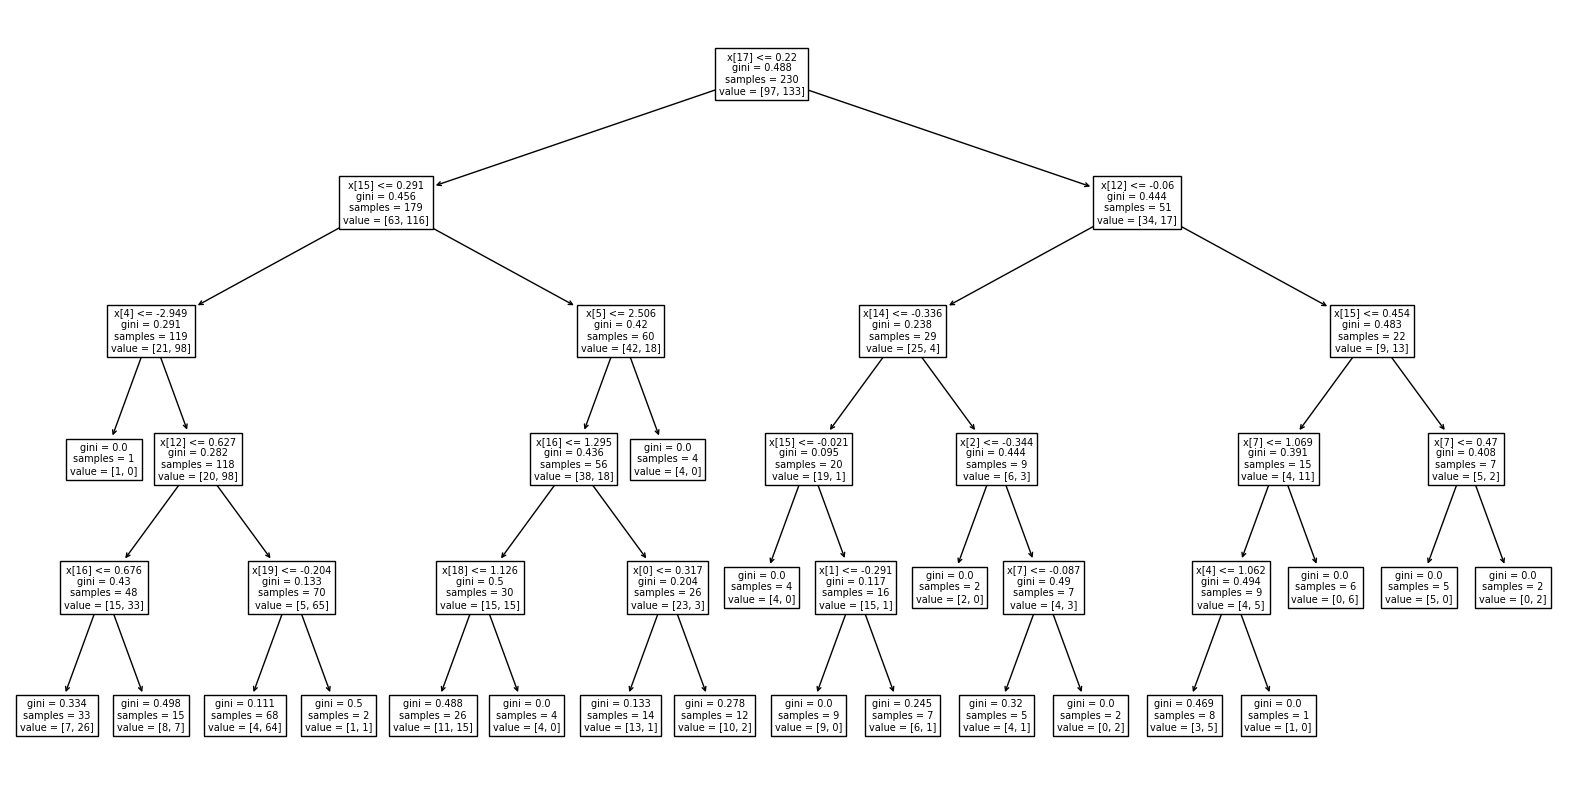

In [78]:
from sklearn import tree

fig, ax = plt.subplots(figsize=(20, 10)) 
tree.plot_tree(tree_model.fit(x_train, y_train), ax=ax)
plt.show()

In [79]:
### svm ###

best.best_params[2]

{'gamma': 'scale', 'kernel': 'linear'}

In [80]:
svm_model = SVC(gamma = 'scale', kernel = 'linear')
svm_model.fit(x_train,y_train)

SVC(kernel='linear')

Train Accuracy 0.9
Train Classification Report
               precision    recall  f1-score   support

           0       0.93      0.82      0.87        97
           1       0.88      0.95      0.92       133

    accuracy                           0.90       230
   macro avg       0.91      0.89      0.90       230
weighted avg       0.90      0.90      0.90       230

Test Accuracy 0.8103448275862069
Test Classification Report
               precision    recall  f1-score   support

           0       0.86      0.70      0.78        27
           1       0.78      0.90      0.84        31

    accuracy                           0.81        58
   macro avg       0.82      0.80      0.81        58
weighted avg       0.82      0.81      0.81        58



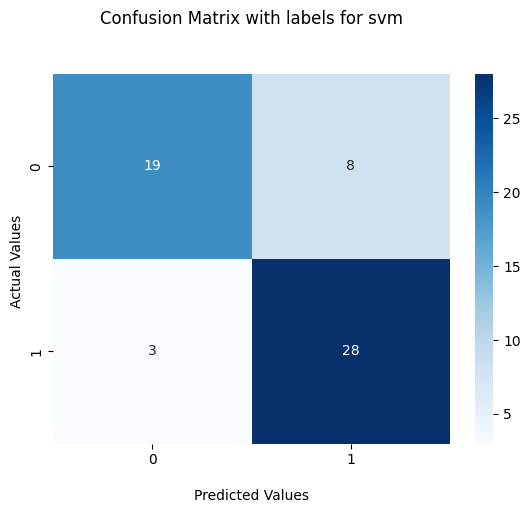

In [81]:
svm_ytrain=svm_model.predict(x_train)
svm_ytest =svm_model.predict(x_test)
print("Train Accuracy", accuracy_score(y_train, svm_ytrain))
print("Train Classification Report\n", classification_report(y_train,svm_ytrain))

print("Test Accuracy", accuracy_score(y_test,svm_ytest))
print("Test Classification Report\n", classification_report(y_test,svm_ytest))
cf_matrix=confusion_matrix(y_test,svm_ytest)
matr = sns.heatmap(cf_matrix, annot=True, cmap='Blues')

matr.set_title('Confusion Matrix with labels for svm\n\n')
matr.set_xlabel('\nPredicted Values')
matr.set_ylabel('Actual Values ')
plt.show()